### Import thư viện

In [35]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load các model đã train

In [36]:


lr_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\linear_model.pkl","rb"))
xgb_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\xgboost_model.pkl","rb"))
prophet_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\prophet_model.pkl","rb"))

### Load dataset

In [37]:

df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")


### Xử lý dữ liệu thiếu

In [38]:
df = df.dropna()

### Chuyển cột thời gian

In [39]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [40]:
##  GỘP THEO NGÀY (QUAN TRỌNG)

In [41]:
df['date'] = df['order_purchase_timestamp'].dt.date
df_daily = df.groupby('date')['payment_value'].sum().reset_index()

df_daily.columns = ['date','revenue']
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values('date')


In [42]:
## FEATURE ENGINEERING (GIỐNG TRAIN)

In [43]:
# ==============================
# FEATURE ENGINEERING (MATCH MODEL)
# ==============================

df_daily['dayofweek'] = df_daily['date'].dt.dayofweek
df_daily['month'] = df_daily['date'].dt.month

df_daily['lag1'] = df_daily['revenue'].shift(1)
df_daily['lag7'] = df_daily['revenue'].shift(7)
df_daily['lag14'] = df_daily['revenue'].shift(14)

df_daily['rolling7'] = df_daily['revenue'].rolling(7).mean()
df_daily['rolling14'] = df_daily['revenue'].rolling(14).mean()

df_daily = df_daily.dropna()

In [44]:
## SPLIT DATA

In [45]:
test_days = 30

test = df_daily.iloc[-test_days:]

X_test = test.drop(columns=['revenue','date'])
y_test = test['revenue']

In [46]:
## PREDICT

In [47]:

X_test = X_test[lr_model.feature_names_in_]

y_pred_lr = lr_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

In [48]:
## EVALUATE LR & XGB

In [49]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

In [50]:
## PROPHET

In [51]:
df_prophet = df_daily[['date','revenue']].copy()
df_prophet.columns = ['ds','y']

train_p = df_prophet.iloc[:-30]
test_p = df_prophet.iloc[-30:]

# ❗ CHỈ dự đoán đúng khoảng test
future = prophet_model.make_future_dataframe(periods=len(test_p), freq='D')

forecast = prophet_model.predict(future)

# Lấy đúng phần test
forecast_test = forecast.iloc[-len(test_p):]

y_pred_prophet = forecast_test['yhat'].values
y_true_prophet = test_p['y'].values

In [52]:
## EVALUATE PROPHET

In [53]:
mae_prophet = mean_absolute_error(y_true_prophet, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_true_prophet, y_pred_prophet))
r2_prophet = r2_score(y_true_prophet, y_pred_prophet)

In [54]:
## SO SÁNH

In [55]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "Prophet"],
    "MAE": [mae_lr, mae_xgb, mae_prophet],
    "RMSE": [rmse_lr, rmse_xgb, rmse_prophet],
    "R2": [r2_lr, r2_xgb, r2_prophet]
})

print(results)

               Model           MAE          RMSE        R2
0  Linear Regression   8202.562579  10801.696269  0.384480
1            XGBoost   1859.441711   2378.011674  0.970168
2            Prophet  11607.086115  14190.187971 -0.062269


In [56]:
## VISUALIZE

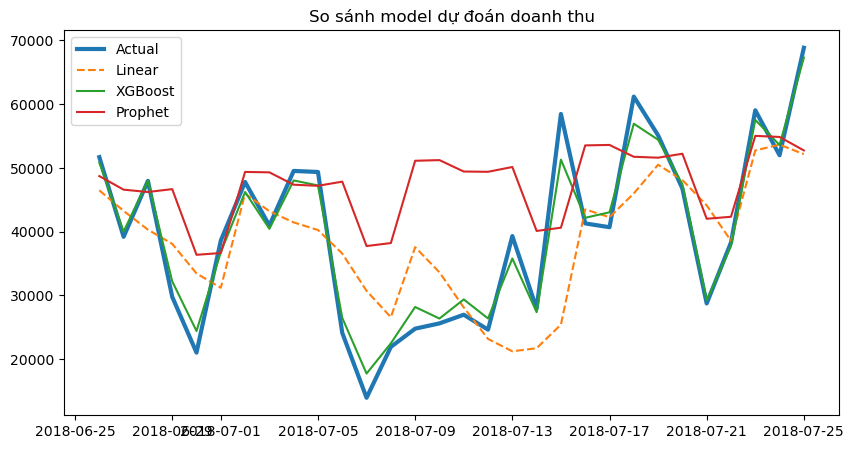

In [57]:
plt.figure(figsize=(10,5))
plt.plot(test['date'], y_test, label='Actual', linewidth=3)
plt.plot(test['date'], y_pred_lr, label='Linear', linestyle='--')
plt.plot(test['date'], y_pred_xgb, label='XGBoost')
plt.plot(test['date'], y_pred_prophet, label='Prophet')
plt.legend()
plt.title("So sánh model dự đoán doanh thu")
plt.show()